In [1]:
!python -m pip install -q prophet yfinance autots skforecast catboost xgboost holidays pybats

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
questionary 2.0.1 requires prompt_toolkit<=3.0.36,>=2.0, but you have prompt-toolkit 3.0.48 which is incompatible.


In [2]:
!pip show pybats

Name: pybats
Version: 0.0.5
Summary: Pybats is a python library for Bayesian time series analysis.
Home-page: https://github.com/lavinei/pybats/tree/master/
Author: Isaac Lavine
Author-email: lavine.isaac@gmail.com
License: Apache Software License 2.0
Location: c:\users\david\appdata\local\programs\python\python310\lib\site-packages
Requires: matplotlib, nbdev, numpy, pandas, scipy, seaborn, statsmodels
Required-by: 


In [3]:
# Base
import pandas as pd 
import json
import logging
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").disabled=True
import warnings
warnings.filterwarnings("ignore")
from joblib import dump, load
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
# Fechas
from datetime import datetime
from datetime import timedelta
from datetime import date
import holidays
# Graficos
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
# Extraer datos
import yfinance as yf
# Modeling
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error, mean_absolute_percentage_error
from autots import AutoTS
from skforecast.ForecasterAutoreg import ForecasterAutoreg
from skforecast.ForecasterAutoregCustom import ForecasterAutoregCustom
from skforecast.ForecasterAutoregDirect import ForecasterAutoregDirect
from catboost import CatBoostRegressor
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import backtesting_forecaster
from skforecast.utils import save_forecaster
from skforecast.utils import load_forecaster
from statsmodels.graphics.tsaplots import plot_acf
from xgboost import XGBRegressor

from pybats.analysis import *
from pybats.point_forecast import *
from pybats.plot import *

$$ACCY = (1 - \frac{|Pronostico -Venta|}{Venta})*100$$

# 1. Load data

In [4]:
msft = yf.Ticker("GOOG")
msft.info
hist = msft.history(period="2y").reset_index().rename(columns={'Date':'ds','Open':'y'})
hist['ds'] = hist['ds'].dt.strftime('%Y-%m-%d')
hist['cap']=hist.y.rolling(window=5).mean().fillna(method='bfill')*1.20
hist['floor']=hist.y.rolling(window=5).mean().fillna(method='bfill')*0.80
hist

,ds,y,High,Low,Close,Volume,Dividends,Stock Splits,cap,floor
0,2022-10-10,99.605384,99.745041,97.630239,98.468178,16529900,0.0,0.0,118.012183,78.674789
1,2022-10-11,98.009306,99.874728,97.011756,97.809799,21617700,0.0,0.0,118.012183,78.674789
2,2022-10-12,98.029256,99.403886,97.430727,98.059189,17343400,0.0,0.0,118.012183,78.674789
3,2022-10-13,95.694990,100.283720,95.036603,99.465729,32812200,0.0,0.0,118.012183,78.674789
4,2022-10-14,100.378493,101.041865,96.792299,96.941933,22624800,0.0,0.0,118.012183,78.674789
...,...,...,...,...,...,...,...,...,...,...
497,2024-10-02,167.759995,168.880005,166.250000,167.309998,12745000,0.0,0.0,199.281599,132.854399
498,2024-10-03,165.820007,167.910004,165.369995,167.210007,11004300,0.0,0.0,199.471201,132.980801
499,2024-10-04,169.339996,169.550003,166.960007,168.559998,11422100,0.0,0.0,200.774399,133.849600
500,2024-10-07,169.139999,169.899994,164.130005,164.389999,14034700,0.0,0.0,201.820800,134.547200


In [17]:
# 1.2 DimTiempo 
start_date = '2014-05-30'
end_date = '2025-12-31'  

DimTiempo = pd.DataFrame({
    'FECHA': pd.date_range(start=start_date, end=end_date, freq='D')
})
# 1.4 DimDS
DimDS = DimTiempo.copy()
DimDS['DS']=np.arange(1,DimTiempo.shape[0]+1,1)

# 1.5 Dimholidays
mx_holidays = holidays.USA()
start_date = '2014-05-01'
end_date = '2024-12-31'
date_range = pd.date_range(start=start_date, end=end_date)
DimHolidays = pd.DataFrame(date_range, columns=['FECHA'])
DimHolidays['HOLIDAY'] = DimHolidays['FECHA'].apply(lambda x: 1 if x in mx_holidays else 0)

# 1.6 DimWeekend
DimWeekend= DimTiempo.copy()
DimWeekend['WEEKEND_X']= DimWeekend['FECHA'].dt.day_of_week
DimWeekend['WEEKEND']= DimWeekend['WEEKEND_X'].apply(lambda x: 1 if x>=5 else 0)
DimWeekend.drop(columns=['WEEKEND_X'],inplace=True)

In [18]:
holidays_USA=\
    pd.concat(
    [
        DimHolidays.query("HOLIDAY==1").reset_index(drop=True).rename(columns={'FECHA':'ds','HOLIDAY':'holiday'}).assign(holiday='usa_holidays',lower_window=-1, upper_window=0)
    ]
)
holidays_USA

,ds,holiday,lower_window,upper_window
0,2014-05-26,usa_holidays,-1,0
1,2014-07-04,usa_holidays,-1,0
2,2014-09-01,usa_holidays,-1,0
3,2014-10-13,usa_holidays,-1,0
4,2014-11-11,usa_holidays,-1,0
...,...,...,...,...
120,2024-09-02,usa_holidays,-1,0
121,2024-10-14,usa_holidays,-1,0
122,2024-11-11,usa_holidays,-1,0
123,2024-11-28,usa_holidays,-1,0


In [19]:
fig = go.Figure()
# Open
fig.add_trace(go.Scatter(x=hist['ds'], y=hist['y'], mode='lines', name='Open',
                         line=dict(color='blue', width=2)))
# High
fig.add_trace(go.Scatter(x=hist['ds'], y=hist['High'], mode='lines', name='High',
                         line=dict(color='green', width=2)))
# Low
fig.add_trace(go.Scatter(x=hist['ds'], y=hist['Low'], mode='lines', name='Low',
                         line=dict(color='red', width=2)))
# Layout
fig.update_layout(
    title='GOOG history',
    xaxis_title='Date',
    yaxis_title='Price',
    legend_title='Legend',
    #template='plotly_dark', 
    hovermode='x'
)
fig.show()

# 2. Prophet

**Fuente:** https://facebook.github.io/prophet/docs/quick_start.html#python-api

El modelo Prophet es un algoritmo de series temporales desarrollado por Facebook, diseñado para manejar datos con patrones estacionales y tendencias. Es especialmente útil para datos con estacionalidad diaria, semanal y anual, y puede manejar datos faltantes y cambios en las tendencias.

**Ecuación del Modelo Prophet**

El modelo Prophet se puede expresar mediante la siguiente ecuación:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

Donde:

- $ y(t) $: es el valor observado en el tiempo $ t $.
- $ g(t) $: es la función de tendencia que modela los cambios no periódicos en la serie temporal.
- $ s(t) $: es la función de estacionalidad que captura las variaciones periódicas (como diaria, semanal o anual).
- $ h(t) $: es la función que modela los eventos o días festivos que pueden afectar los valores de la serie temporal.
- $ \epsilon_t $: es el término de error que captura la variabilidad no explicada por el modelo.

### Componentes del Modelo

1. **Tendencia ($g(t)$)**: Puede ser modelada usando dos tipos de funciones:
    - **Lineal**: $g(t) = k t + m$, donde $k$ es la pendiente y $m$ es la intersección.
    - **Crecimiento Logístico**: $$g(t) = \frac{C}{1 + \exp(-k(t - m))}$$, donde $ C $ es la capacidad de saturación, $ k $ es la tasa de crecimiento y $ m $ es el punto medio del crecimiento.

2. **Estacionalidad ($ s(t) $)**: Modelada usando una serie de Fourier para capturar las variaciones periódicas:
    $s(t) = \sum_{n=1}^{N} \left( a_n \cos\left(\frac{2 \pi n t}{P}\right) + b_n \cos\left(\frac{2 \pi n t}{P}\right) \right)$
    Donde $ P $ es el periodo de la estacionalidad (por ejemplo, 365.25 para anual).

3. **Festivos ($ h(t) $)**: Modela el efecto de los eventos especiales o días festivos utilizando variables indicadoras para cada evento.

4. **Ruido ($ \epsilon_t $)**: Captura las irregularidades y ruidos no explicados por los otros componentes del modelo.

El modelo Prophet es robusto, fácil de usar y ofrece una interfaz intuitiva para la previsión de series temporales complejas.


## 2.1 Evaluacion

In [31]:
# Metricas
model = Prophet(
            growth='linear', # linear, flat, logistic. Si ellijes logistic se debe crear una columna llamada 'cap' para cada fila con el valor maximo posible
            #changepoints= 5, # NOT USE puntos de cambio de la serie de tiempo, por default son 25
            #changepoint_range=0.8, # NOT USE esto indica que los 25 puntos se van a poner sobre el primer 80% de las series
            changepoint_prior_scale=0.1, # DEFAULT 0.05 Parametro que modula la felxibilidad de seleccion de puntos de cambio, mientras mas pequeño menor puntos de cambios
            holidays=holidays_USA,
            holidays_prior_scale=0.05
        )
#model.add_seasonality(name='weekly', period=7, fourier_order=3, prior_scale=0.1)
model.add_seasonality(name='daily', period=1, fourier_order=2, prior_scale=0.05)
model.add_seasonality(name='weekly', period=7, fourier_order=3, prior_scale=0.05)
model.add_seasonality(name='yearly', period=365.25, fourier_order=10, prior_scale=0.05)

#model.add_regressor('new_users');model.add_regressor('retained_users');model.add_regressor('t2m');
#model.add_regressor('total_usd');model.add_regressor('discount_promo');model.add_regressor('discount_coupon');model.add_regressor('freq_ret')
model.fit(hist[['ds','y']].iloc[0:-30].fillna(method='backfill').fillna(method='bfill').fillna(method='ffill'))

prophet    INFO  Found custom seasonality named 'yearly', disabling built-in 'yearly' seasonality.
prophet    INFO  Found custom seasonality named 'weekly', disabling built-in 'weekly' seasonality.
prophet    INFO  Found custom seasonality named 'daily', disabling built-in 'daily' seasonality.


**Comentarios importantes**
- `fourier_order` controla la complejidad de la estacionalidad. Más alto permite que el modelo ajuste patrones más complejos.
- `prior_scale` controla la flexibilidad de la estacionalidad. Más bajo hace que la estacionalidad sea más regular y menos propensa a sobreajustar el ruido en los datos.

In [35]:
test = hist.iloc[-30:][['ds']]
f_t=model.predict(test)

fig = go.Figure()
# Open
fig.add_trace(go.Scatter(x=hist.iloc[0:-30]['ds'], y=hist.iloc[0:-30]['y'], mode='lines', name='Open',
                         line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=f_t[['ds','yhat']]['ds'], y=f_t[['ds','yhat']]['yhat'], mode='lines', name='Pred',
                         line=dict(color='red', width=2)))
fig.add_trace(go.Scatter(x=hist.iloc[-30:]['ds'], y=hist.iloc[-30:]['y'], mode='lines', name='Test',
                         line=dict(color='green', width=2)))

# Layout
fig.update_layout(
    title='GOOGLE history Back Testing',
    xaxis_title='Date',
    yaxis_title='Price',
    legend_title='Legend',
    #template='plotly_dark', 
    hovermode='x'
)
fig.show()

In [33]:
# Error metrics
print('MSE: ', mean_squared_error(y_true=hist.iloc[-30:]['y'].values, y_pred=f_t['yhat'].values))
print('RMSE: ', np.sqrt(mean_squared_error(y_true=hist.iloc[-30:]['y'].values, y_pred=f_t['yhat'].values)))
print('MAE: ', mean_absolute_error(y_true=hist.iloc[-30:]['y'].values, y_pred=f_t['yhat'].values))
print('Max Error: ', max_error(y_true=hist.iloc[-30:]['y'].values, y_pred=f_t['yhat'].values))
print('MAPE: ', mean_absolute_percentage_error(y_true=hist.iloc[-30:]['y'].values, y_pred=f_t['yhat'].values)*100)

MSE:  70.29781488092759
RMSE:  8.384379218578296
MAE:  7.457747905316751
Max Error:  15.353259817001032
MAPE:  4.635638517874599


In [34]:
# ACCY
real=hist.iloc[-30:]['y'].values
pred=f_t['yhat'].values
assert real.shape== pred.shape
accu=(1- np.abs(pred-real)/real)*100
np.nanmean(accu)

95.3643614821254

## 2.2 Prediccion

In [36]:
model = Prophet(
            growth='linear', # linear, flat, logistic. Si ellijes logistic se debe crear una columna llamada 'cap' para cada fila con el valor maximo posible
            #changepoints= 5, # NOT USE puntos de cambio de la serie de tiempo, por default son 25
            #changepoint_range=0.8, # NOT USE esto indica que los 25 puntos se van a poner sobre el primer 80% de las series
            changepoint_prior_scale=0.1, # DEFAULT 0.05 Parametro que modula la felxibilidad de seleccion de puntos de cambio, mientras mas pequeño menor puntos de cambios
            holidays=holidays_USA,
            holidays_prior_scale=0.05
        )
model.add_seasonality(name='daily', period=1, fourier_order=2, prior_scale=0.05)
model.add_seasonality(name='weekly', period=7, fourier_order=3, prior_scale=0.05)
model.add_seasonality(name='yearly', period=365.25, fourier_order=10, prior_scale=0.05)
#model.add_regressor('new_users');model.add_regressor('retained_users');model.add_regressor('t2m');
#model.add_regressor('total_usd');model.add_regressor('discount_promo');model.add_regressor('discount_coupon');model.add_regressor('freq_ret')
model.fit(hist[['ds','y']].fillna(method='backfill').fillna(method='bfill').fillna(method='ffill'))

prophet    INFO  Found custom seasonality named 'yearly', disabling built-in 'yearly' seasonality.
prophet    INFO  Found custom seasonality named 'weekly', disabling built-in 'weekly' seasonality.
prophet    INFO  Found custom seasonality named 'daily', disabling built-in 'daily' seasonality.


In [37]:
future = model.make_future_dataframe(periods=5).tail(5)
#future['cap']= hist.iloc[-30:].cap.values
#future['floor']= 0# hist.iloc[-30:].floor.values
forecast = model.predict(future)
forecast.head(5)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-10-09,164.262512,160.609907,170.235649,164.262512,164.262512,0.745537,0.745537,0.745537,0.171242,...,-0.026909,-0.026909,-0.026909,0.601204,0.601204,0.601204,0.0,0.0,0.0,165.008048
1,2024-10-10,164.304289,160.332475,169.554160,164.304289,164.304289,0.576083,0.576083,0.576083,0.171242,...,0.024590,0.024590,0.024590,0.380251,0.380251,0.380251,0.0,0.0,0.0,164.880372
2,2024-10-11,164.346066,160.025311,169.110955,164.346066,164.346066,0.318720,0.318720,0.318720,0.171242,...,0.066656,0.066656,0.066656,0.080822,0.080822,0.080822,0.0,0.0,0.0,164.664786
3,2024-10-12,164.387843,159.443455,168.995024,164.387843,164.387843,-0.167423,-0.167423,-0.167423,0.171242,...,-0.042811,-0.042811,-0.042811,-0.295855,-0.295855,-0.295855,0.0,0.0,0.0,164.220420
4,2024-10-13,164.429620,159.575904,168.721030,164.429620,164.429620,-0.393459,-0.393459,-0.393459,0.171242,...,-0.042810,-0.042810,-0.042810,-0.747005,-0.747005,-0.747005,0.0,0.0,0.0,164.036162


In [38]:
fig = go.Figure()
# Open
fig.add_trace(go.Scatter(x=hist['ds'], y=hist['y'], mode='lines', name='Open',
                         line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=forecast[['ds','yhat']]['ds'], y=forecast[['ds','yhat']]['yhat'], mode='lines', name='Pred',
                         line=dict(color='red', width=2)))

# Layout
fig.update_layout(
    title='GOOGLE history',
    xaxis_title='Date',
    yaxis_title='Price',
    legend_title='Legend',
    #template='plotly_dark', 
    hovermode='x'
)
fig.show()

# 3. AutoTS

AutoTS (Automated Time Series) es una librería de Python diseñada para simplificar y automatizar el proceso de modelado y predicción de series temporales. La librería proporciona herramientas que permiten a los usuarios generar rápidamente modelos precisos de series temporales sin necesidad de una intervención manual significativa en la selección de modelos, ajuste de hiperparámetros y evaluación de rendimiento.

**Referencia**: https://github.com/winedarksea/autots

**Modelos Clásicos**

1. **ARIMA (AutoRegressive Integrated Moving Average)**: Modelo popular para series temporales estacionarias que combina componentes autorregresivos, de media móvil y de diferenciación.
2. **ETS (Error, Trend, Seasonal)**: Modelo que descompone la serie temporal en error, tendencia y estacionalidad.
3. **Prophet**: Modelo desarrollado por Facebook para capturar tendencias y estacionalidades con soporte para eventos especiales y cambios abruptos en las tendencias.

**Modelos de Machine Learning**

1. **Random Forest**: Modelo de ensamble que utiliza múltiples árboles de decisión para mejorar la precisión de las predicciones.
2. **XGBoost**: Modelo de boosting que combina árboles de decisión para realizar predicciones robustas y precisas.

**Modelos de Deep Learning**

1. **LSTM (Long Short-Term Memory)**: Tipo de red neuronal recurrente (RNN) especialmente útil para capturar dependencias a largo plazo en las series temporales.
2. **GRU (Gated Recurrent Unit)**: Variante simplificada de LSTM que también es eficaz para modelar dependencias a largo plazo.

**Otros Modelos**

1. **VAR (Vector AutoRegression)**: Modelo que captura la relación entre múltiples series temporales.
2. **NBEATS**: Modelo avanzado de deep learning diseñado específicamente para series temporales.


## 3.1 Evaluación

In [39]:
C= hist.copy()
C['ds'] = pd.to_datetime(C['ds'])
C_weekly = C.groupby(pd.Grouper(key='ds', freq='W')).mean()
C_weekly = C_weekly.reset_index()
C_weekly['ds'] = C_weekly['ds'].dt.strftime('%Y-%W')
C_weekly['ds_new']= np.arange(1, C_weekly.shape[0]+1,1)
C_weekly

,ds,y,High,Low,Close,Volume,Dividends,Stock Splits,cap,floor,ds_new
0,2022-41,98.343486,100.069848,96.780325,98.148965,22185600.0,0.00,0.0,118.012183,78.674789,1
1,2022-42,100.441331,102.202806,99.355002,100.646828,24121920.0,0.00,0.0,119.736666,79.824444,2
2,2022-43,97.558413,99.509621,96.186382,98.138988,43165740.0,0.00,0.0,119.548968,79.699312,3
3,2022-44,90.604490,91.195041,87.614830,88.267229,41065320.0,0.00,0.0,112.143473,74.762315,4
4,2022-45,90.197491,91.923255,89.336608,90.948650,31351220.0,0.00,0.0,106.148120,70.765413,5
...,...,...,...,...,...,...,...,...,...,...,...
100,2024-37,153.468399,154.860999,151.210599,153.121994,21041800.0,0.04,0.0,186.176638,124.117758,101
101,2024-38,161.722003,162.440002,160.476401,161.592001,21377960.0,0.00,0.0,189.706945,126.471296,102
102,2024-39,164.300000,165.569400,163.016998,163.764001,15973840.0,0.00,0.0,196.843682,131.229121,103
103,2024-40,167.312000,168.828003,165.823999,167.738000,13574200.0,0.00,0.0,198.936960,132.624640,104


<Axes: >

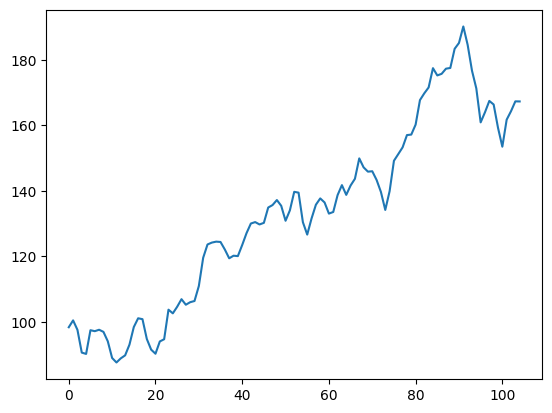

In [40]:
C_weekly.y.plot()

In [41]:
T=C_weekly[['ds','y']].iloc[0:-15].fillna(method='backfill').fillna(method='bfill').fillna(method='ffill')
T['ds'] = pd.to_datetime(T['ds'] + '-1', format='%Y-%W-%w')
T=T.set_index('ds')
T

,y
ds,
2022-10-10,98.343486
2022-10-17,100.441331
2022-10-24,97.558413
2022-10-31,90.604490
2022-11-07,90.197491
...,...
2024-05-27,175.229664
2024-06-03,175.719466
2024-06-10,177.289022


In [48]:
T=C_weekly[['ds','y']].iloc[0:-15].fillna(method='backfill').fillna(method='bfill').fillna(method='ffill')
T['ds'] = pd.to_datetime(T['ds'] + '-1', format='%Y-%W-%w')
T=T.set_index('ds')

steps_to_predict= 15

model = AutoTS(
        forecast_length=steps_to_predict,
        frequency='W', # D= Daily , W= Weekly, Y= Yearly, M='Monthly'
        prediction_interval=0.9,
        max_generations=5,
        no_negatives=True, # Todo lo negativo se redondea a 0
        #ensemble='auto', # 'auto', 'simple', 'distance', 'horizontal', 'horizontal-min', 'horizontal-max', "mosaic", "subsample"
        ensemble=['auto'],
        #model_list="fast",  # "fast","superfast", "default", "fast_parallel", "univariate"
        # 'ETS', 'GLM', 'UnobservedComponents', 'UnivariateMotif', 'MultivariateMotif', 'Theta', 'ARDL', 'ARCH'
        model_list=['ETS','UnobservedComponents','GLM','ARCH','Theta', 'ARDL','LastValueNaive','GLS','AverageValueNaive'],
        #model_list=['ETS','UnobservedComponents','GLM','ARCH','Theta','ARDL','LastValueNaive','GLS','AverageValueNaive','ConstantNaive','SeasonalNaive','DynamicFactor',\
        #            'DynamicFactorMQ','VECM','VAR','RollingRegression','RollingRegression','WindowRegression','DatepartRegression','MultivariateRegression',\
        #            'FFT','Cassandra','KalmanStateSpace','LATC'
        #            ],
        transformer_list="fast",  # "fast","superfast",
        drop_most_recent=1,
        num_validations=3,
        validation_method="backwards", # 'even', 'backwards', or 'seasonal n',
        verbose=0, # -1
        constraint=0.4,  # forecasts would not be allowed to go above max(training data) + 1.3 * st.dev(training data), as well as the reverse on the minimum side 
)
model.fit(T)

Template Eval Error: ValueError('x must have 2 complete cycles requires 104 observations. x only has 74 observation(s)') in model 21 in generation 0: Theta
Template Eval Error: ImportError('`arch` package must be installed from pip') in model 22 in generation 0: ARCH
Template Eval Error: ValueError('The first guess on the deviance function returned a nan.  This could be a boundary  problem and should be reported.') in model 25 in generation 0: GLM
Template Eval Error: ImportError('`arch` package must be installed from pip') in model 26 in generation 0: ARCH
Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 28 in generation 0: ARDL
Template Eval Error: ImportError('`arch` package must be installed from pip') in model 38 in generation 0: ARCH
Template Eval Error: ImportError('`arch` package must be installed from pip') in model 39 in generation 0: ARCH
Template Eval Error: Exception('Transformer DatepartRegression failed on inverse') in 

Initiated AutoTS object with best model: 
ARDL
{'fillna': 'rolling_mean', 'transformations': {'0': 'SeasonalDifference', '1': 'Round', '2': 'ClipOutliers'}, 'transformation_params': {'0': {'lag_1': 7, 'method': 5}, '1': {'model': 'middle', 'decimals': 0, 'on_transform': False, 'on_inverse': True}, '2': {'method': 'clip', 'std_threshold': 2, 'fillna': None}}}
{'lags': 1, 'trend': 'ct', 'order': 0, 'causal': False, 'regression_type': None}
Validation: 0, 1, 2, 3
SMAPE: 9.240877896626646, 2.789026926998226, 2.909880651527225, 12.350009875160287
MAE: 14.759597630642737, 3.9459161266522433, 3.8686488443953087, 14.29564432351358
SPL: 2.640896945309507, 1.1280504151966988, 0.9074157430687704, 3.0966941705931506

In [49]:
pred=model.predict(forecast_length=steps_to_predict) # Tambien pronostica otras variables
pred    

Prediction object: 
Return .forecast, 
 .upper_forecast, 
 .lower_forecast 
 .model_parameters 
 .transformation_parameters

In [50]:
pred.model_parameters

{'lags': 1,
 'trend': 'ct',
 'order': 0,
 'causal': False,
 'regression_type': None}

In [51]:
pred.transformation_parameters

{'fillna': 'rolling_mean',
 'transformations': {'0': 'SeasonalDifference',
  '1': 'Round',
  '2': 'ClipOutliers'},
 'transformation_params': {'0': {'lag_1': 7, 'method': 5},
  '1': {'model': 'middle',
   'decimals': 0,
   'on_transform': False,
   'on_inverse': True},
  '2': {'method': 'clip', 'std_threshold': 2, 'fillna': None}}}

In [52]:
f_t= pred.forecast
f_t=f_t.reset_index().rename(columns={'index':'ds'})
f_t['ds_new']= np.arange(C_weekly.iloc[0:-15].ds_new.max()+1, C_weekly.iloc[0:-15].ds_new.max()+1+15,1)
f_t

,ds,y,ds_new
0,2024-06-30,169.532121,91
1,2024-07-07,170.805593,92
2,2024-07-14,173.966875,93
3,2024-07-21,174.448857,94
4,2024-07-28,174.722453,95
5,2024-08-04,176.597343,96
6,2024-08-11,180.748469,97
7,2024-08-18,173.532121,98
8,2024-08-25,175.805593,99
9,2024-09-01,179.966875,100


In [53]:
f_t= pred.forecast
f_t=f_t.reset_index().rename(columns={'index':'ds'})
f_t['ds_new']= np.arange(C_weekly.iloc[0:-15].ds_new.max()+1, C_weekly.iloc[0:-15].ds_new.max()+1+15,1)

fig = go.Figure()
# Open
fig.add_trace(go.Scatter(x=C_weekly.iloc[0:-15]['ds_new'], y=C_weekly.iloc[0:-15]['y'], mode='lines', name='Open',
                         line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=f_t[['ds_new','y']]['ds_new'], y=f_t[['ds_new','y']]['y'], mode='lines', name='Pred',
                         line=dict(color='red', width=2)))
fig.add_trace(go.Scatter(x=C_weekly.iloc[-15:]['ds_new'], y=C_weekly.iloc[-15:]['y'], mode='lines', name='Test',
                         line=dict(color='green', width=2)))

# Layout
fig.update_layout(
    title='GOOG history',
    xaxis_title='Date',
    yaxis_title='Price',
    legend_title='Legend',
    #template='plotly_dark', 
    hovermode='x'
)
fig.show()

In [54]:
print('MSE: ', mean_squared_error(y_true=C_weekly.iloc[-15:]['y'].values, y_pred=f_t['y'].values))
print('RMSE: ', np.sqrt(mean_squared_error(y_true=C_weekly.iloc[-15:]['y'].values, y_pred=f_t['y'].values)))
print('MAE: ', mean_absolute_error(y_true=C_weekly.iloc[-15:]['y'].values, y_pred=f_t['y'].values))
print('Max Error: ', max_error(y_true=C_weekly.iloc[-15:]['y'].values, y_pred=f_t['y'].values))
print('MAPE: ', mean_absolute_percentage_error(y_true=C_weekly.iloc[-15:]['y'].values, y_pred=f_t['y'].values)*100)

MSE:  248.6620507398144
RMSE:  15.769021870103877
MAE:  14.331364860899036
Max Error:  25.98045815854161
MAPE:  8.580765468564804


## 3.2 Predicción

In [55]:
T=C_weekly[['ds','y']].fillna(method='backfill').fillna(method='bfill').fillna(method='ffill')
T['ds'] = pd.to_datetime(T['ds'] + '-1', format='%Y-%W-%w')
T=T.set_index('ds')

steps_to_predict= 15

model = AutoTS(
        forecast_length=steps_to_predict,
        frequency='W', # Daily , W= Weekly, Y= Yearly
        prediction_interval=0.9,
        max_generations=5,
        no_negatives=True, # Todo lo negativo se redondea a 0
        #ensemble='auto', # 'auto', 'simple', 'distance', 'horizontal', 'horizontal-min', 'horizontal-max', "mosaic", "subsample"
        ensemble=['auto'],
        #model_list="fast",  # "fast","superfast", "default", "fast_parallel", "univariate"
        # 'ETS', 'GLM', 'UnobservedComponents', 'UnivariateMotif', 'MultivariateMotif', 'Theta', 'ARDL', 'ARCH'
        model_list=['ETS','UnobservedComponents','GLM','ARCH','Theta', 'ARDL','LastValueNaive','GLS','AverageValueNaive'],
        #model_list=['ETS','UnobservedComponents','GLM','ARCH','Theta','ARDL','LastValueNaive','GLS','AverageValueNaive','ConstantNaive','SeasonalNaive','DynamicFactor',\
        #            'DynamicFactorMQ','VECM','VAR','RollingRegression','RollingRegression','WindowRegression','DatepartRegression','MultivariateRegression',\
        #            'FFT','Cassandra','KalmanStateSpace','LATC'
        #            ],
        transformer_list="fast",  # "fast","superfast",
        drop_most_recent=1,
        num_validations=3,
        validation_method="backwards", # 'even', 'backwards', or 'seasonal n',
        verbose=0, # -1
        constraint=0.4,  # forecasts would not be allowed to go above max(training data) + 1.3 * st.dev(training data), as well as the reverse on the minimum side 
)
model.fit(T)

Template Eval Error: ValueError('x must have 2 complete cycles requires 104 observations. x only has 89 observation(s)') in model 21 in generation 0: Theta
Template Eval Error: ImportError('`arch` package must be installed from pip') in model 22 in generation 0: ARCH
Template Eval Error: ValueError('The first guess on the deviance function returned a nan.  This could be a boundary  problem and should be reported.') in model 25 in generation 0: GLM
Template Eval Error: ImportError('`arch` package must be installed from pip') in model 26 in generation 0: ARCH
Template Eval Error: ValueError("regression_type='User' but future_regressor not supplied") in model 28 in generation 0: ARDL
Template Eval Error: ImportError('`arch` package must be installed from pip') in model 38 in generation 0: ARCH
Template Eval Error: ImportError('`arch` package must be installed from pip') in model 39 in generation 0: ARCH
Template Eval Error: ImportError('`arch` package must be installed from pip') in model

Initiated AutoTS object with best model: 
ARDL
{'fillna': 'pchip', 'transformations': {'0': 'ClipOutliers', '1': 'Detrend', '2': 'MinMaxScaler', '3': 'AlignLastValue'}, 'transformation_params': {'0': {'method': 'clip', 'std_threshold': 2, 'fillna': None}, '1': {'model': 'Linear', 'phi': 1, 'window': 90, 'transform_dict': {'fillna': None, 'transformations': {'0': 'bkfilter'}, 'transformation_params': {'0': {}}}}, '2': {}, '3': {'rows': 1, 'lag': 1, 'method': 'additive', 'strength': 1.0, 'first_value_only': False}}}
{'lags': 1, 'trend': 'c', 'order': 0, 'causal': False, 'regression_type': None}
Validation: 0, 1, 2, 3
SMAPE: 7.582096533677147, 10.501587659411467, 2.656964725948829, 2.5929367624955213
MAE: 13.1047800609835, 16.612644778368846, 3.743795113431109, 3.467726019505734
SPL: 2.223243512637953, 3.2353446621748576, 0.8800940949378906, 0.6929874514686754

In [56]:
pred=model.predict(forecast_length=steps_to_predict) # Tambien pronostica otras variables
pred    

Prediction object: 
Return .forecast, 
 .upper_forecast, 
 .lower_forecast 
 .model_parameters 
 .transformation_parameters

In [57]:
f_t= pred.forecast
f_t=f_t.reset_index().rename(columns={'index':'ds'})
f_t['ds_new']= np.arange(C_weekly.ds_new.max()+1, C_weekly.ds_new.max()+1+15,1)

fig = go.Figure()
# Open
fig.add_trace(go.Scatter(x=C_weekly['ds_new'], y=C_weekly['y'], mode='lines', name='Open',
                         line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=f_t[['ds_new','y']]['ds_new'], y=f_t[['ds_new','y']]['y'], mode='lines', name='Pred',
                         line=dict(color='red', width=2)))

# Layout
fig.update_layout(
    title='MSFT history',
    xaxis_title='Date',
    yaxis_title='Price',
    legend_title='Legend',
    #template='plotly_dark', 
    hovermode='x'
)
fig.show()

# 4. DLGM

<Axes: >

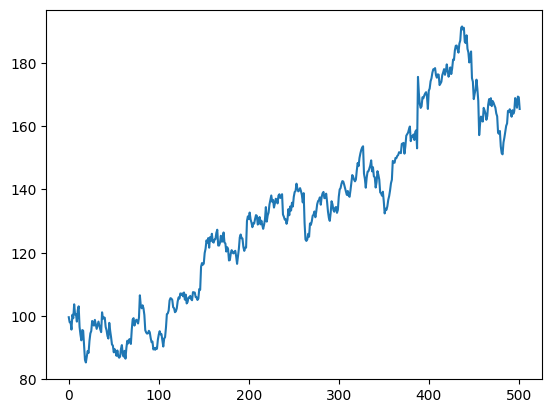

In [58]:
hist.y.plot()

In [60]:
hist

,ds,y,High,Low,Close,Volume,Dividends,Stock Splits,cap,floor
0,2022-10-10,99.605384,99.745041,97.630239,98.468178,16529900,0.0,0.0,118.012183,78.674789
1,2022-10-11,98.009306,99.874728,97.011756,97.809799,21617700,0.0,0.0,118.012183,78.674789
2,2022-10-12,98.029256,99.403886,97.430727,98.059189,17343400,0.0,0.0,118.012183,78.674789
3,2022-10-13,95.694990,100.283720,95.036603,99.465729,32812200,0.0,0.0,118.012183,78.674789
4,2022-10-14,100.378493,101.041865,96.792299,96.941933,22624800,0.0,0.0,118.012183,78.674789
...,...,...,...,...,...,...,...,...,...,...
497,2024-10-02,167.759995,168.880005,166.250000,167.309998,12745000,0.0,0.0,199.281599,132.854399
498,2024-10-03,165.820007,167.910004,165.369995,167.210007,11004300,0.0,0.0,199.471201,132.980801
499,2024-10-04,169.339996,169.550003,166.960007,168.559998,11422100,0.0,0.0,200.774399,133.849600
500,2024-10-07,169.139999,169.899994,164.130005,164.389999,14034700,0.0,0.0,201.820800,134.547200


In [61]:
data_combination=hist
k = 1                                          # Forecast 1 step ahead
forecast_start = 0 
forecast_end = data_combination.shape[0]-1
data_combination
# Model Base
mod, samples = analysis(data_combination['y'].values, 
                        #data_combination[exog_cols].values, 
                        family="poisson",
                        forecast_start=forecast_start,      # First time step to forecast on
                        forecast_end=forecast_end,          # Final time step to forecast on
                        k=1,                                # Forecast horizon. If k>1, default is to forecast 1:k steps ahead, marginally
                        prior_length=5,                     # How many data point to use in defining prior
                        rho=.5,                             # Random effect extension, which increases the forecast variance (see Berry and West, 2019)
                        deltrend=0.95,                      # Discount factor on the trend component (the intercept)
                        delregn=0.95                        # Discount factor on the regression component
)

In [62]:
pred_0=np.median(mod.forecast_marginal(k=1,nsamps=100))
mod.update(y=pred_0)

In [63]:
lista_forecasts=[]
lista_forecasts.append(pred_0)
for i in range(13-1):
    #print('Procesando iteracion: ',i+1)
    pred_i= np.median(mod.forecast_marginal(k=1,nsamps=1000))
    lista_forecasts.append(pred_i)
    mod.update(y=pred_i)

In [64]:
lista_forecasts

[166.0,
 165.0,
 165.0,
 164.5,
 164.5,
 166.0,
 164.0,
 165.0,
 165.0,
 165.0,
 164.5,
 165.0,
 164.0]

In [65]:
t=pd.DataFrame()
t['pred']=lista_forecasts
t     

,pred
0,166.0
1,165.0
2,165.0
3,164.5
4,164.5
5,166.0
6,164.0
7,165.0
8,165.0
9,165.0


# 5. Skforecast

**Referencia:** https://skforecast.org/0.12.1/index.html

## 5.1 Evaluación

In [66]:
T=C_weekly[['ds','y']].iloc[0:-15].fillna(method='backfill').fillna(method='bfill').fillna(method='ffill')
T['ds'] = pd.to_datetime(T['ds'] + '-1', format='%Y-%W-%w')
T['ds_new']= np.arange(0, T.shape[0],1)
T

,ds,y,ds_new
0,2022-10-10,98.343486,0
1,2022-10-17,100.441331,1
2,2022-10-24,97.558413,2
3,2022-10-31,90.604490,3
4,2022-11-07,90.197491,4
...,...,...,...
85,2024-05-27,175.229664,85
86,2024-06-03,175.719466,86
87,2024-06-10,177.289022,87
88,2024-06-17,177.508832,88


In [67]:
forecaster= ForecasterAutoreg(
    regressor =CatBoostRegressor(random_state= 123, silent=True), 
    lags= 24,
    #transformer_y = PowerTransformer()
)

param_grid= {'n_estimators': [30,50,100],'max_depth':[5, 10],'learning_rate':[0.1, 0.01]}
lags_grid =[1,3,6,12,24]

result_grid= grid_search_forecaster(
            forecaster= forecaster,
            y= T['y'],
            #exog= data_train[exog_cols],
            param_grid= param_grid,
            lags_grid= lags_grid,
            steps=steps_to_predict,
            #refit=True,
            metric= 'mean_squared_error',
            initial_train_size= int(len(T)*0.7),
            return_best=True,
            n_jobs='auto',
            verbose=False,
            show_progress= False
)
path_model= f"./model_CatBoost_GLOBAL_F.py"
save_forecaster(forecaster, file_name=path_model, verbose=False)

ruta_exog=f"./model_CatBoost_GLOBAL_F.py"
forecaster_loaded = load(f"{ruta_exog}")

Number of models compared: 60.
`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [1] 
  Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100}
  Backtesting metric: 607.8743035619908



In [68]:
# Crear y entrenar forecaster
dss= list(T.ds_new)
ys= list(T.y)
preds= []
# ==============================================================================
for i in range(15):
   forecaster = ForecasterAutoreg(
                  #regressor = CatBoostRegressor(random_state= 123, silent=True, learning_rate=0.1, max_depth=10, n_estimators=100),
                  regressor = XGBRegressor(random_state= 123, silent=True, learning_rate=0.1, max_depth=10, n_estimators=50),
                  lags =1
               )
   U=pd.DataFrame()
   U['ds']= dss 
   U['y']= ys
   #U= U.set_index('ds')
   forecaster.fit(y=U['y'])
   predicciones = forecaster.predict(steps=1).values[0]
   dss.append(U['ds'].max()+1)
   ys.append(predicciones)
   preds.append(predicciones)
   print(preds)
   

[179.9022674560547]
[179.9022674560547, 180.25778198242188]
[179.9022674560547, 180.25778198242188, 179.47415161132812]
[179.9022674560547, 180.25778198242188, 179.47415161132812, 180.52955627441406]
[179.9022674560547, 180.25778198242188, 179.47415161132812, 180.52955627441406, 179.29396057128906]
[179.9022674560547, 180.25778198242188, 179.47415161132812, 180.52955627441406, 179.29396057128906, 180.64683532714844]
[179.9022674560547, 180.25778198242188, 179.47415161132812, 180.52955627441406, 179.29396057128906, 180.64683532714844, 179.21017456054688]
[179.9022674560547, 180.25778198242188, 179.47415161132812, 180.52955627441406, 179.29396057128906, 180.64683532714844, 179.21017456054688, 180.7454071044922]
[179.9022674560547, 180.25778198242188, 179.47415161132812, 180.52955627441406, 179.29396057128906, 180.64683532714844, 179.21017456054688, 180.7454071044922, 179.16612243652344]
[179.9022674560547, 180.25778198242188, 179.47415161132812, 180.52955627441406, 179.29396057128906, 18

In [69]:
f_t= pd.DataFrame()
f_t['pred']= preds
f_t['ds_new']= np.arange(T['ds_new'].max()+1,T['ds_new'].max()+1+15)


fig = go.Figure()
# Open
fig.add_trace(go.Scatter(x=C_weekly.iloc[0:-15]['ds_new'], y=C_weekly.iloc[0:-15]['y'], mode='lines', name='Open',
                         line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=f_t[['ds_new','pred']]['ds_new'], y=f_t[['ds_new','pred']]['pred'], mode='lines', name='Pred',
                         line=dict(color='red', width=2)))
fig.add_trace(go.Scatter(x=C_weekly.iloc[-15:]['ds_new'], y=C_weekly.iloc[-15:]['y'], mode='lines', name='Test',
                         line=dict(color='green', width=2)))

# Layout
fig.update_layout(
    title='MSFT history',
    xaxis_title='Date',
    yaxis_title='Price',
    legend_title='Legend',
    #template='plotly_dark', 
    hovermode='x'
)
fig.show()

In [70]:
print('MSE: ', mean_squared_error(y_true=C_weekly.iloc[-15:]['y'].values, y_pred=f_t['pred'].values))
print('RMSE: ', np.sqrt(mean_squared_error(y_true=C_weekly.iloc[-15:]['y'].values, y_pred=f_t['pred'].values)))
print('MAE: ', mean_absolute_error(y_true=C_weekly.iloc[-15:]['y'].values, y_pred=f_t['pred'].values))
print('Max Error: ', max_error(y_true=C_weekly.iloc[-15:]['y'].values, y_pred=f_t['pred'].values))
print('MAPE: ', mean_absolute_percentage_error(y_true=C_weekly.iloc[-15:]['y'].values, y_pred=f_t['pred'].values)*100)

MSE:  215.7798117678143
RMSE:  14.689445590893289
MAE:  13.337372106862501
Max Error:  25.666885375976562
MAPE:  8.088898118453645
